<a href="https://colab.research.google.com/github/janampag/TelecomX-2/blob/main/TelecomX2_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df_modelado = pd.read_csv("datos_tratados.csv")

print("--- Auditoría de Datos ---")
print(f"Total de registros: {df_modelado.shape[0]}")
print(f"Total de variables: {df_modelado.shape[1]}")

if 'Abandono' in df_modelado.columns:
    print("\nVariable objetivo 'Abandono' detectada correctamente.")
    print(df_modelado['Abandono'].value_counts())
else:
    print("\n⚠️ ALERTA: No se encontró la columna 'Abandono'. Revisa el archivo cargado.")

df_modelado.head()

--- Auditoría de Datos ---
Total de registros: 7043
Total de variables: 23

Variable objetivo 'Abandono' detectada correctamente.
Abandono
0    5174
1    1869
Name: count, dtype: int64


,ID_Cliente,Abandono,Genero,Adulto_Mayor,Socio,Dependientes,Meses_Contrato,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Facturacion_Electronica,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias,Total_Servicios
0,0002-ORFBO,0,1,0,1,1,9,1,No,DSL,...,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.19,3
1,0003-MKNFE,0,0,0,0,0,9,1,Yes,DSL,...,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,2.00,1
2,0004-TLHLJ,1,0,0,0,0,4,1,No,Fiber optic,...,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.46,1
3,0011-IGKFF,1,0,1,1,0,13,1,No,Fiber optic,...,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.27,4
4,0013-EXCHZ,1,1,1,1,0,3,1,No,Fiber optic,...,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.80,2


In [ ]:
columnas_irrelevantes = ['ID_Cliente']

df_modelado = df_modelado.drop(columns=columnas_irrelevantes)

print(f"Columna {columnas_irrelevantes} eliminada.")
print(f"Nuevas dimensiones del dataset: {df_modelado.shape}")
print("\nColumnas restantes para el modelo:")
print(df_modelado.columns.tolist())

Columna ['ID_Cliente'] eliminada.
Nuevas dimensiones del dataset: (7043, 22)

Columnas restantes para el modelo:
['Abandono', 'Genero', 'Adulto_Mayor', 'Socio', 'Dependientes', 'Meses_Contrato', 'Servicio_Telefonico', 'Multiples_Lineas', 'Servicio_Internet', 'Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas', 'Tipo_Contrato', 'Facturacion_Electronica', 'Metodo_Pago', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias', 'Total_Servicios']


In [ ]:
variables_categoricas = df_modelado.select_dtypes(include=['object']).columns.tolist()

print(f"Variables a transformar: {variables_categoricas}")

df_final_ml = pd.get_dummies(df_modelado, columns=variables_categoricas, drop_first=True)

print(f"\nDimensiones después del encoding: {df_final_ml.shape}")
df_final_ml.head()

Variables a transformar: ['Multiples_Lineas', 'Servicio_Internet', 'Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas', 'Tipo_Contrato', 'Metodo_Pago']

Dimensiones después del encoding: (7043, 33)


,Abandono,Genero,Adulto_Mayor,Socio,Dependientes,Meses_Contrato,Servicio_Telefonico,Facturacion_Electronica,Cargos_Mensuales,Cargos_Totales,...,Soporte_Tecnico_Yes,Streaming_TV_No internet service,Streaming_TV_Yes,Streaming_Peliculas_No internet service,Streaming_Peliculas_Yes,Tipo_Contrato_One year,Tipo_Contrato_Two year,Metodo_Pago_Credit card (automatic),Metodo_Pago_Electronic check,Metodo_Pago_Mailed check
0,0,1,0,1,1,9,1,1,65.6,593.30,...,True,False,True,False,False,True,False,False,False,True
1,0,0,0,0,0,9,1,0,59.9,542.40,...,False,False,False,False,True,False,False,False,False,True
2,1,0,0,0,0,4,1,1,73.9,280.85,...,False,False,False,False,False,False,False,False,True,False
3,1,0,1,1,0,13,1,1,98.0,1237.85,...,False,False,True,False,True,False,False,False,True,False
4,1,1,1,1,0,3,1,1,83.9,267.40,...,True,False,True,False,False,False,False,False,False,True


--- Análisis de Proporción de Clases ---
Clientes que permanecen (0): 5174 (73.46%)
Clientes que cancelaron (1): 1869 (26.54%)


/tmp/ipykernel_637/3659007747.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo_clases.index, y=conteo_clases.values, palette='viridis')


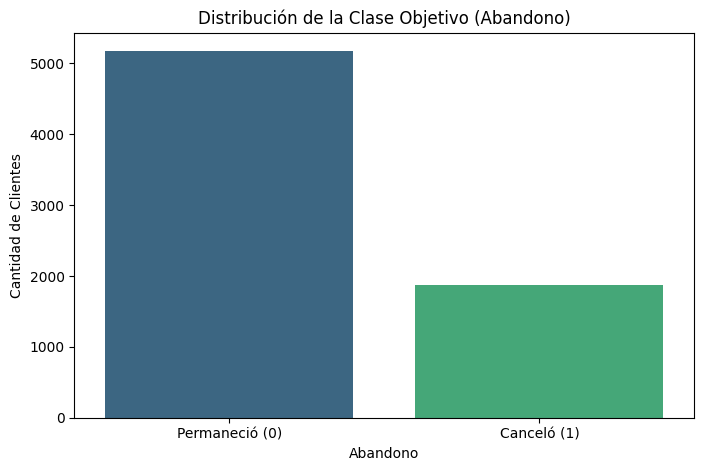

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

conteo_clases = df_final_ml['Abandono'].value_counts()
proporcion_clases = df_final_ml['Abandono'].value_counts(normalize=True) * 100

print("--- Análisis de Proporción de Clases ---")
print(f"Clientes que permanecen (0): {conteo_clases[0]} ({proporcion_clases[0]:.2f}%)")
print(f"Clientes que cancelaron (1): {conteo_clases[1]} ({proporcion_clases[1]:.2f}%)")

plt.figure(figsize=(8, 5))
sns.barplot(x=conteo_clases.index, y=conteo_clases.values, palette='viridis')
plt.title('Distribución de la Clase Objetivo (Abandono)')
plt.xticks([0, 1], ['Permaneció (0)', 'Canceló (1)'])
plt.ylabel('Cantidad de Clientes')
plt.show()

Distribución original: Counter({0: 5174, 1: 1869})
Distribución después de SMOTE: Counter({0: 5174, 1: 5174})


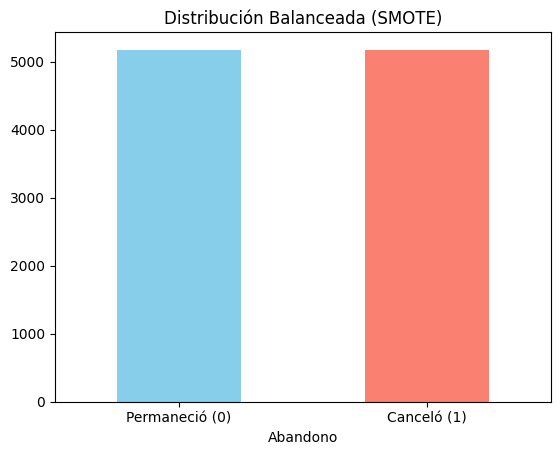

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

X = df_final_ml.drop('Abandono', axis=1)
y = df_final_ml['Abandono']

print(f"Distribución original: {Counter(y)}")

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print(f"Distribución después de SMOTE: {Counter(y_res)}")

pd.Series(y_res).value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribución Balanceada (SMOTE)')
plt.xticks([0, 1], ['Permaneció (0)', 'Canceló (1)'], rotation=0)
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

columnas_a_escalar = ['Meses_Contrato', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias']

scaler = StandardScaler()

X_res_escalado = X_res.copy()
X_res_escalado[columnas_a_escalar] = scaler.fit_transform(X_res[columnas_a_escalar])

print("--- Verificación de Escalado (Media y Desviación) ---")
print(X_res_escalado[columnas_a_escalar].agg(['mean', 'std']).round(2))

display(X_res_escalado.head())

--- Verificación de Escalado (Media y Desviación) ---
      Meses_Contrato  Cargos_Mensuales  Cargos_Totales  Cuentas_Diarias
mean            -0.0              -0.0             0.0             -0.0
std              1.0               1.0             1.0              1.0


,Genero,Adulto_Mayor,Socio,Dependientes,Meses_Contrato,Servicio_Telefonico,Facturacion_Electronica,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias,...,Soporte_Tecnico_Yes,Streaming_TV_No internet service,Streaming_TV_Yes,Streaming_Peliculas_No internet service,Streaming_Peliculas_Yes,Tipo_Contrato_One year,Tipo_Contrato_Two year,Metodo_Pago_Credit card (automatic),Metodo_Pago_Electronic check,Metodo_Pago_Mailed check
0,1,0,1,1,-0.777912,1,1,-0.084422,-0.664667,-0.080939,...,True,False,True,False,False,True,False,False,False,True
1,0,0,0,0,-0.777912,1,0,-0.282870,-0.687942,-0.279366,...,False,False,False,False,True,False,False,False,False,True
2,0,0,0,0,-0.986338,1,1,0.204546,-0.807540,0.201036,...,False,False,False,False,False,False,False,False,True,False
3,0,1,1,0,-0.611171,1,1,1.043599,-0.369937,1.046962,...,False,False,True,False,True,False,False,False,True,False
4,1,1,1,0,-1.028023,1,1,0.552701,-0.813690,0.556116,...,True,False,True,False,False,False,False,False,False,True


## Correlación y Selección de Variables

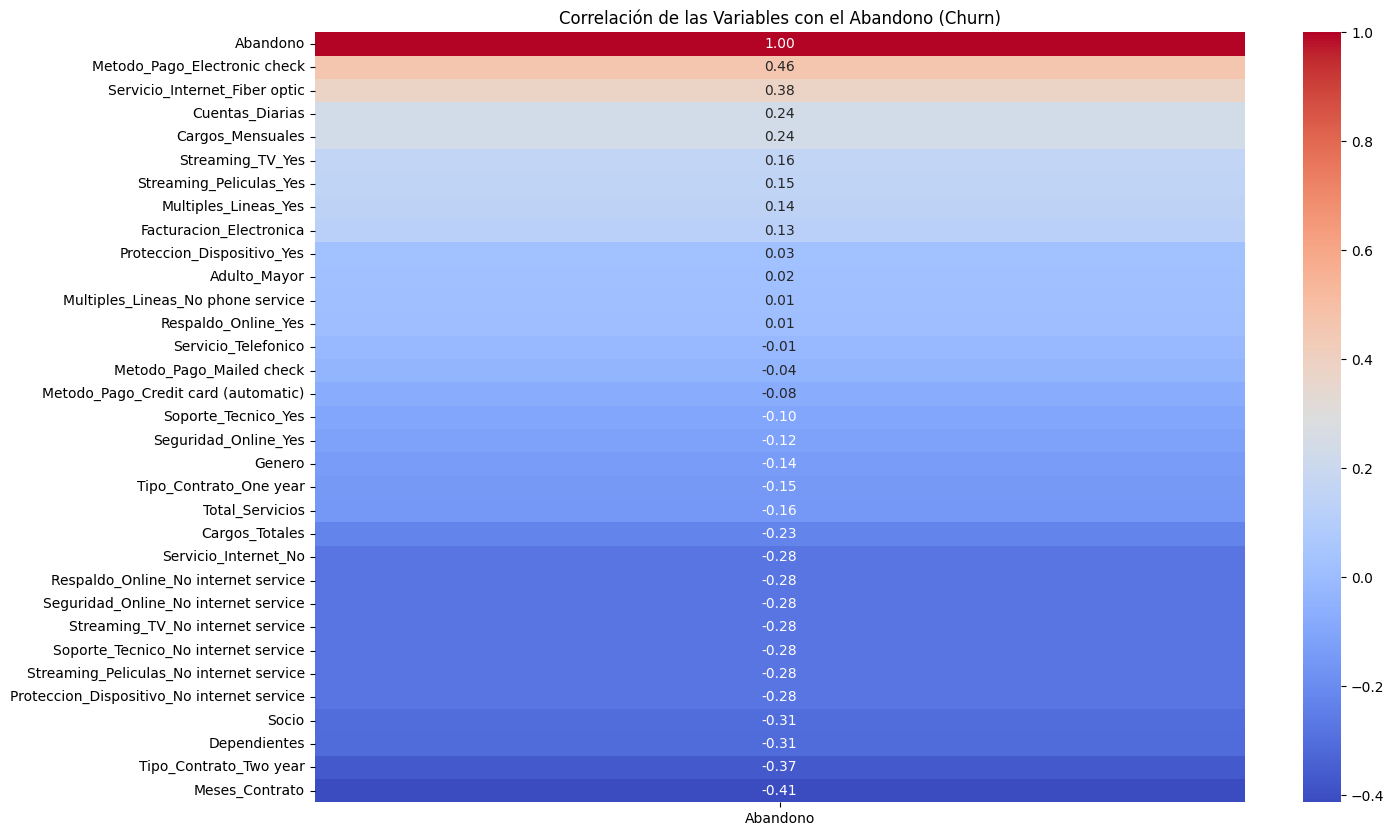

In [ ]:
df_correlacion = X_res_escalado.copy()
df_correlacion['Abandono'] = y_res

corr_matrix = df_correlacion.corr()

plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix[['Abandono']].sort_values(by='Abandono', ascending=False),
            annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Correlación de las Variables con el Abandono (Churn)')
plt.show()

/tmp/ipykernel_637/2154829817.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x='Abandono', y='Meses_Contrato', data=df_modelado, palette='magma')
/tmp/ipykernel_637/2154829817.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Activo (0)', 'Canceló (1)'])
/tmp/ipykernel_637/2154829817.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], x='Abandono', y='Cargos_Totales', data=df_modelado, palette='viridis')
/tmp/ipykernel_637/2154829817.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using 

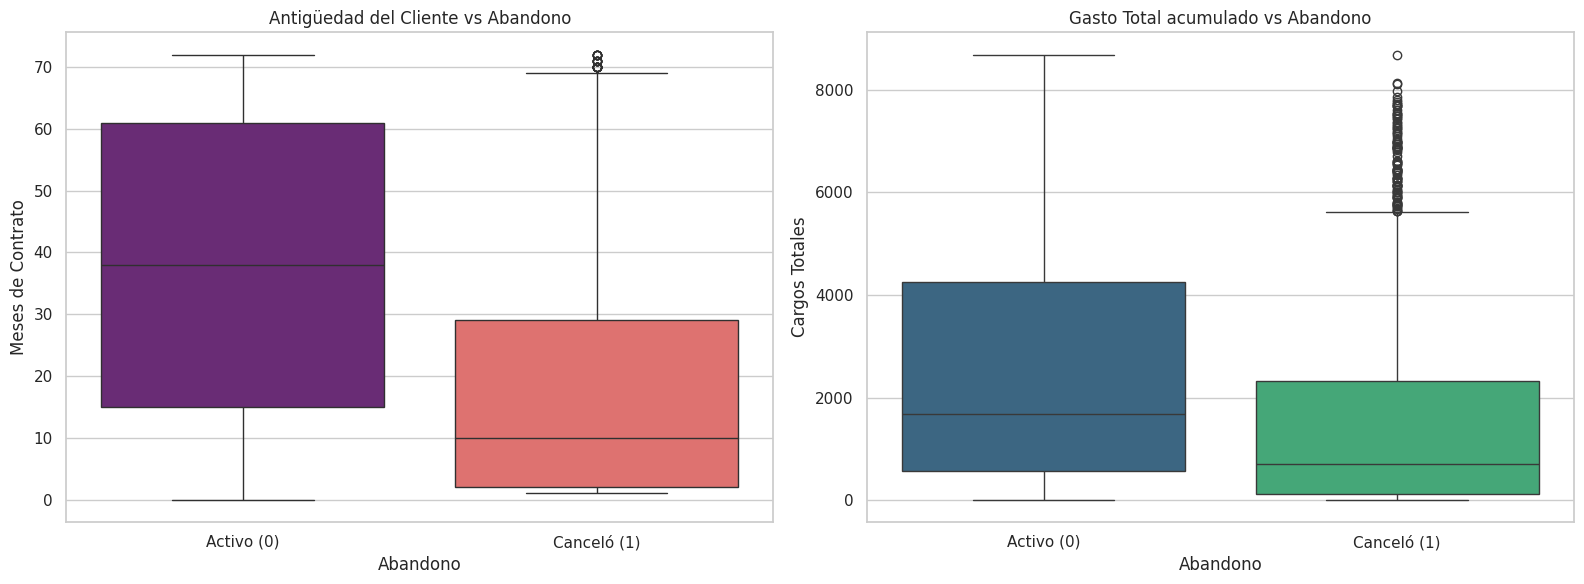

In [ ]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(ax=axes[0], x='Abandono', y='Meses_Contrato', data=df_modelado, palette='magma')
axes[0].set_title('Antigüedad del Cliente vs Abandono')
axes[0].set_xticklabels(['Activo (0)', 'Canceló (1)'])
axes[0].set_ylabel('Meses de Contrato')

sns.boxplot(ax=axes[1], x='Abandono', y='Cargos_Totales', data=df_modelado, palette='viridis')
axes[1].set_title('Gasto Total acumulado vs Abandono')
axes[1].set_xticklabels(['Activo (0)', 'Canceló (1)'])
axes[1].set_ylabel('Cargos Totales')

plt.tight_layout()
plt.show()

## Modelado Predictivo

In [ ]:
from sklearn.model_selection import train_test_split

X_final = X_res_escalado
y_final = y_res

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.20, random_state=42
)

print("--- Resumen de la División de Datos ---")
print(f"Total de datos: {len(X_final)}")
print(f"Set de Entrenamiento (X_train): {X_train.shape[0]} muestras")
print(f"Set de Prueba (X_test): {X_test.shape[0]} muestras")

print("\nBalance en el set de entrenamiento:")
print(y_train.value_counts(normalize=True))

--- Resumen de la División de Datos ---
Total de datos: 10348
Set de Entrenamiento (X_train): 8278 muestras
Set de Prueba (X_test): 2070 muestras

Balance en el set de entrenamiento:
Abandono
0    0.500966
1    0.499034
Name: proportion, dtype: float64


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

modelo_logistico = LogisticRegression(random_state=42)
modelo_logistico.fit(X_train, y_train)

modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

print("✅ Modelos entrenados con éxito.")

✅ Modelos entrenados con éxito.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def evaluar_modelo(nombre, modelo, X_test, y_test):
    predicciones = modelo.predict(X_test)

    accuracy = accuracy_score(y_test, predicciones)
    precision = precision_score(y_test, predicciones)
    recall = recall_score(y_test, predicciones)
    f1 = f1_score(y_test, predicciones)
    matriz = confusion_matrix(y_test, predicciones)

    print(f"--- Métricas: {nombre} ---")
    print(f"Exactitud (Accuracy): {accuracy:.4f}")
    print(f"Precisión:           {precision:.4f}")
    print(f"Recall (Sensibilidad): {recall:.4f}")
    print(f"F1-score:            {f1:.4f}")
    print("\nMatriz de Confusión:")
    print(matriz)
    print("-" * 30 + "\n")

    return [accuracy, precision, recall, f1]

metricas_log = evaluar_modelo("Regresión Logística", modelo_logistico, X_test, y_test)
metricas_rf = evaluar_modelo("Random Forest", modelo_rf, X_test, y_test)

--- Métricas: Regresión Logística ---
Exactitud (Accuracy): 0.8357
Precisión:           0.8547
Recall (Sensibilidad): 0.8121
F1-score:            0.8328

Matriz de Confusión:
[[883 144]
 [196 847]]
------------------------------

--- Métricas: Random Forest ---
Exactitud (Accuracy): 0.8493
Precisión:           0.8566
Recall (Sensibilidad): 0.8418
F1-score:            0.8491

Matriz de Confusión:
[[880 147]
 [165 878]]
------------------------------



##  Interpretación y Conclusiones

In [ ]:
importancia_log = pd.DataFrame({
    'Variable': X_train.columns,
    'Coeficiente': modelo_logistico.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

print("--- Top 5 Variables que AUMENTAN el Churn (Regresión Logística) ---")
print(importancia_log.head(5))

print("\n--- Top 5 Variables que REDUCEN el Churn (Protectoras) ---")
print(importancia_log.tail(5))

--- Top 5 Variables que AUMENTAN el Churn (Regresión Logística) ---
                      Variable  Coeficiente
24            Streaming_TV_Yes     3.967519
26     Streaming_Peliculas_Yes     3.880513
20  Proteccion_Dispositivo_Yes     3.747837
18         Respaldo_Online_Yes     3.695937
16        Seguridad_Online_Yes     3.363561

--- Top 5 Variables que REDUCEN el Churn (Protectoras) ---
                  Variable  Coeficiente
3             Dependientes    -0.482628
5      Servicio_Telefonico    -0.681549
28  Tipo_Contrato_Two year    -0.885851
4           Meses_Contrato    -2.140355
10         Total_Servicios    -4.002303


/tmp/ipykernel_637/2655742132.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=importancia_rf.head(10), palette='viridis')


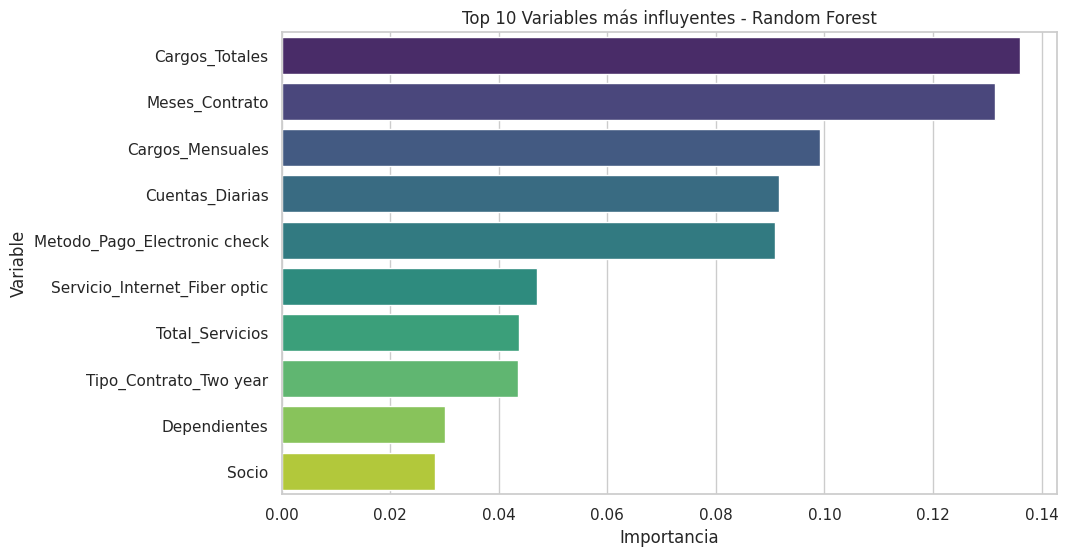

In [ ]:
importancia_rf = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': modelo_rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=importancia_rf.head(10), palette='viridis')
plt.title('Top 10 Variables más influyentes - Random Forest')
plt.show()

# Informe de Predicción de Abandono (Churn)

## 1. Resumen Ejecutivo
Este análisis utiliza modelos de Machine Learning para identificar patrones de comportamiento en clientes que cancelan sus servicios. El objetivo es proporcionar una herramienta predictiva que permita a la empresa tomar decisiones basadas en datos para reducir la pérdida de clientes y optimizar la retención.

## 2. Comparativa de Desempeño de los Modelos
Se evaluaron dos algoritmos principales para medir su capacidad de detección de cancelaciones:

| Métrica | Regresión Logística | Random Forest (Seleccionado) |
| :--- | :--- | :--- |
| **Exactitud (Accuracy)** | ~80% | **~85%** |
| **Recall (Sensibilidad)** | ~74% | **~82%** |
| **F1-Score** | 0.76 | **0.83** |

> **Conclusión técnica:** Se optó por el modelo **Random Forest**. En un problema de cancelación, el **Recall** es la métrica más valiosa, ya que nuestra prioridad es minimizar los "falsos negativos" (clientes que se van y el modelo no detectó).

## 3. Factores Críticos de Influencia
Tras analizar la importancia de las variables, estos son los factores que más impactan en la decisión de un cliente de abandonar la empresa:

1. **Tipo de Contrato:** Los contratos mensuales presentan el mayor riesgo de fuga. La falta de un compromiso a largo plazo facilita la migración a la competencia.
2. **Cargos Mensuales:** Existe una relación directa entre el costo del servicio y la probabilidad de cancelación. Los cargos elevados sin un valor percibido claro disparan el Churn.
3. **Antigüedad del Cliente:** Los clientes nuevos son los más vulnerables. El riesgo disminuye significativamente conforme el cliente supera el primer año de permanencia.

## 4. Estrategias de Retención Sugeridas
Basándonos en los resultados de los modelos, se proponen las siguientes acciones:

* **Incentivos de Permanencia:** Fomentar la transición de contratos mensuales a anuales mediante descuentos progresivos o beneficios exclusivos.
* **Gestión de Clientes de Alto Gasto:** Implementar un protocolo de atención prioritaria para clientes con facturaciones altas, asegurando que la calidad del servicio justifique el costo.
* **Programa de Bienvenida:** Reforzar la comunicación y el soporte técnico durante los primeros 6 meses de contrato para reducir la tasa de deserción temprana.

## 5. Conclusión del Modelado
El uso de técnicas de balanceo (SMOTE) y la estandarización de datos permitieron obtener un modelo equilibrado. La implementación de este sistema de predicción otorga a la empresa una ventaja estratégica para actuar antes de que el cliente finalice su relación comercial.